**K-ortalamalar (K-Means)**

Bu uygulamada, K-ortalamalar kümeleme algoritmasının, farklı zorluk seviyelerine sahip sentetik veri kümeleri üzerinde küme içi varyansı minimize ederek etiketlenmemiş verileri nasıl grupladığını gösterilmektedir. Farklı K değerlerinin seçilmesinin etkileri incelenmiş, performansı Dirsek (Elbow) Yöntemi ve Silhouette Skoru kullanarak analiz edilmiş ve ölçeklendirmeye duyarlılık ile küresel olmayan (non-spherical) verilerde başarısızlık gibi önemli sınırlamaları ortaya konulmuştur.

Modüllerin yüklenmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

sns.set(style="whitegrid")
np.random.seed(42)

Basit Sentetik Veri Oluştur (İyi Ayrışmış Kümeler)

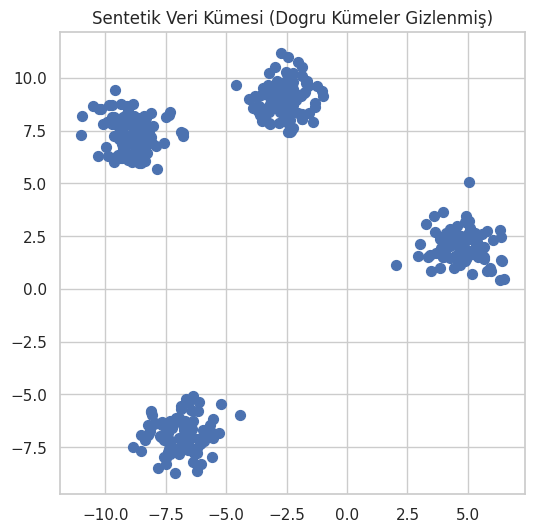

In [2]:
X, y_true = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=50)
plt.title("Sentetik Veri Kümesi (Dogru Kümeler Gizlenmiş)")
plt.show()

In [19]:
X

array([[ -9.86267124,   8.72735826],
       [ -4.60499371,   9.67180813],
       [ -9.03492221,   7.10534406],
       [  5.41997462,   1.85552378],
       [  5.09659124,   2.8816222 ],
       [ -3.13580026,   8.75663692],
       [ -2.13060752,   8.956023  ],
       [ -8.42420054,   6.74292786],
       [ -2.43955997,   8.77508025],
       [  5.80079372,   2.74058634],
       [ -8.70163541,   7.17633625],
       [  3.89833446,   1.9255494 ],
       [ -7.33270816,   8.39985895],
       [  4.06763587,   2.51684788],
       [ -7.26971217,  -7.22615614],
       [ -6.84080989,  -7.54486969],
       [ -6.47889344,  -7.66215379],
       [ -2.60171625,   8.77340317],
       [  4.16838703,   2.65285136],
       [ -6.64780731,  -5.21978895],
       [  4.26233334,   2.84433016],
       [ -8.57742134,   6.32263205],
       [ -2.9447038 ,   9.1030242 ],
       [  2.04686496,   1.15365957],
       [ -2.66308639,   9.255524  ],
       [ -9.47070732,   7.7006976 ],
       [ -6.54887927,  -5.37867294],
 

Veriye uygulama

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

Grafikleştirme

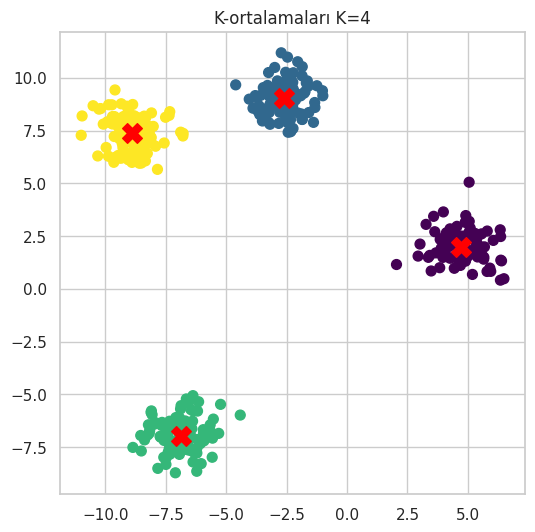

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap="viridis", s=50)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-ortalamaları K=4")
plt.show()

Yanlış K Seçersek Ne Olur?


Durum 1: Çok Az Küme (Yetersiz Küme Sayısı)

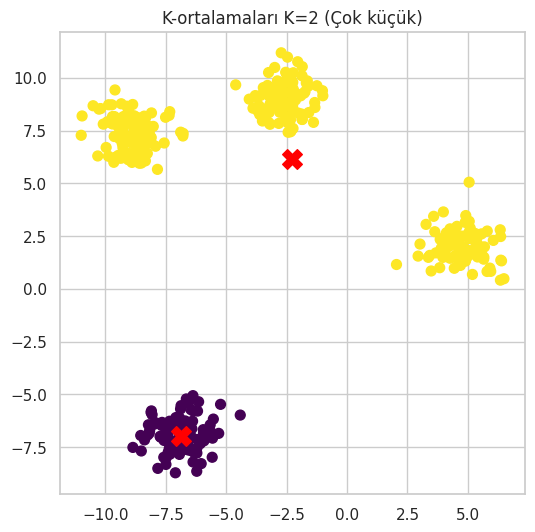

In [20]:
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters2 = kmeans2.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=clusters2, cmap="viridis", s=50)
plt.scatter(kmeans2.cluster_centers_[:,0],
            kmeans2.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-ortalamaları K=2 (Çok küçük)")
plt.show()

Durum iki : Çok Fazla Küme Sayısı

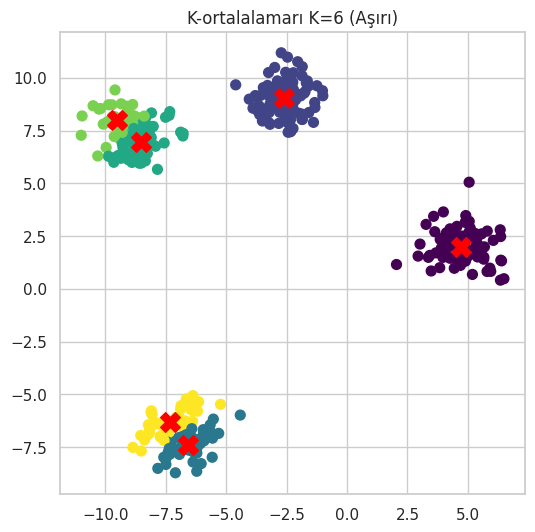

In [21]:
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters6 = kmeans6.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=clusters6, cmap="viridis", s=50)
plt.scatter(kmeans6.cluster_centers_[:,0],
            kmeans6.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-ortalalamarı K=6 (Aşırı)")
plt.show()

Dirsek Yöntemi (Sistematik K Seçimi)

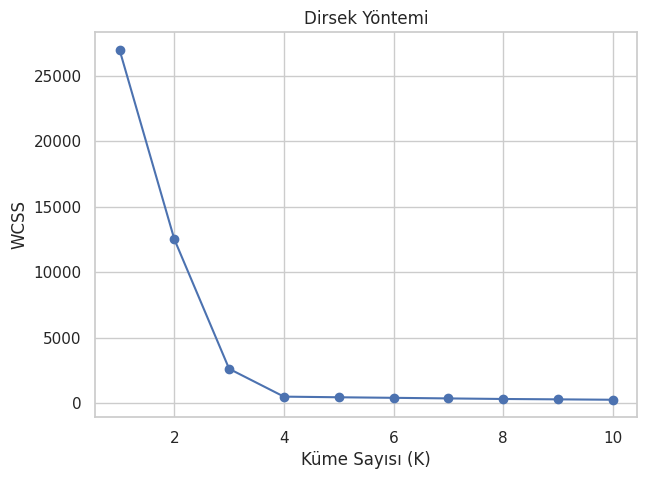

In [7]:
wcss = [] #Küme İçi Kareler Toplamı

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Küme Sayısı (K)")
plt.ylabel("WCSS")
plt.title("Dirsek Yöntemi")
plt.show()

Silüet Skoru Karşılaştırması

In [8]:
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.604
K=3, Silhouette Score=0.779
K=4, Silhouette Score=0.835
K=5, Silhouette Score=0.724
K=6, Silhouette Score=0.584
K=7, Silhouette Score=0.454


Problemi Zorlaştırmak (İç İçe Geçmiş/Örtüşen Kümeler)

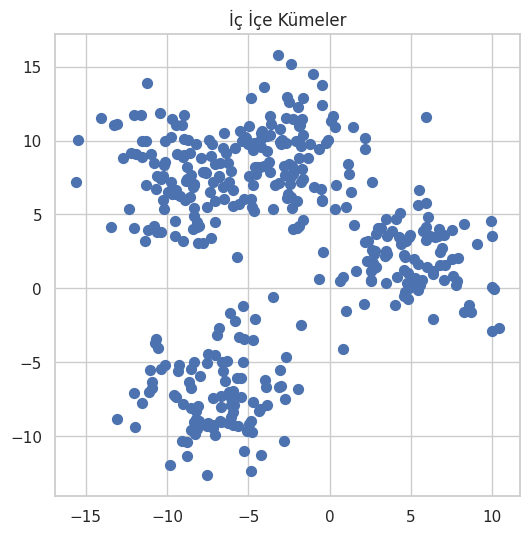

In [9]:
X_overlap, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=2.5,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_overlap[:,0], X_overlap[:,1], s=50)
plt.title("İç İçe Kümeler")
plt.show()

K-ortalamalarının uygulanması :

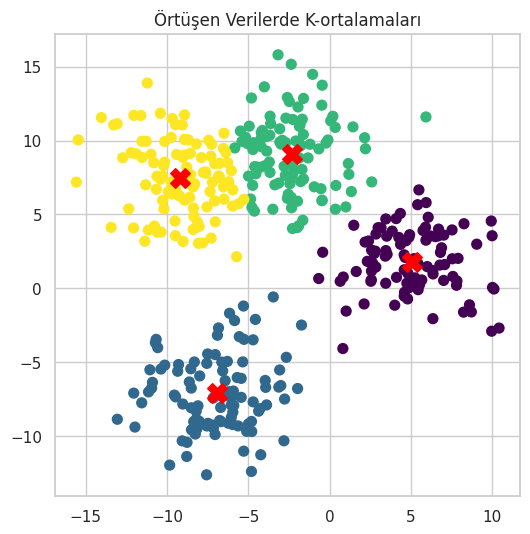

In [22]:
kmeans_overlap = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_overlap = kmeans_overlap.fit_predict(X_overlap)

plt.figure(figsize=(6,6))
plt.scatter(X_overlap[:,0], X_overlap[:,1], c=labels_overlap, cmap="viridis", s=50)
plt.scatter(kmeans_overlap.cluster_centers_[:,0],
            kmeans_overlap.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Örtüşen Verilerde K-ortalamaları")
plt.show()

Küresel Olmayan Kümeler (Yanlış Sonuç Verme Durumu)

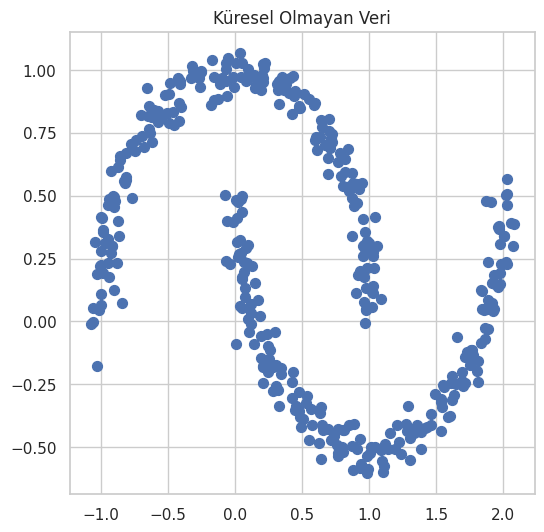

In [11]:
from sklearn.datasets import make_moons

X_moon, _ = make_moons(n_samples=400, noise=0.05, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], s=50)
plt.title("Küresel Olmayan Veri")
plt.show()

K-ortalamaları uygulanınca :

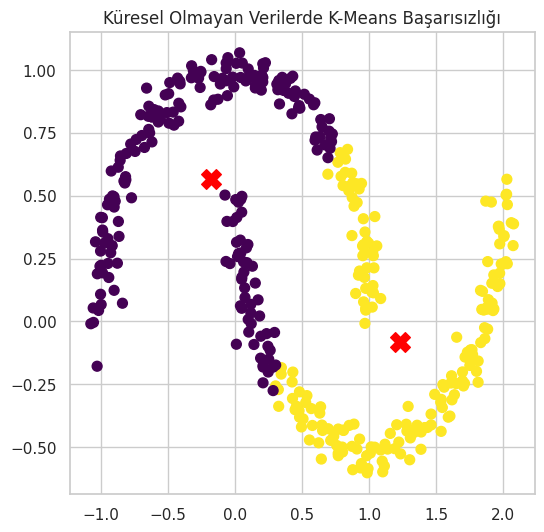

In [23]:
kmeans_moon = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_moon = kmeans_moon.fit_predict(X_moon)

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], c=labels_moon, cmap="viridis", s=50)
plt.scatter(kmeans_moon.cluster_centers_[:,0],
            kmeans_moon.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Küresel Olmayan Verilerde K-Means Başarısızlığı")
plt.show()

Ölçeklendirmenin Önemi

Farklı özellik ölçeklerine sahip veri kümesi oluşturma:

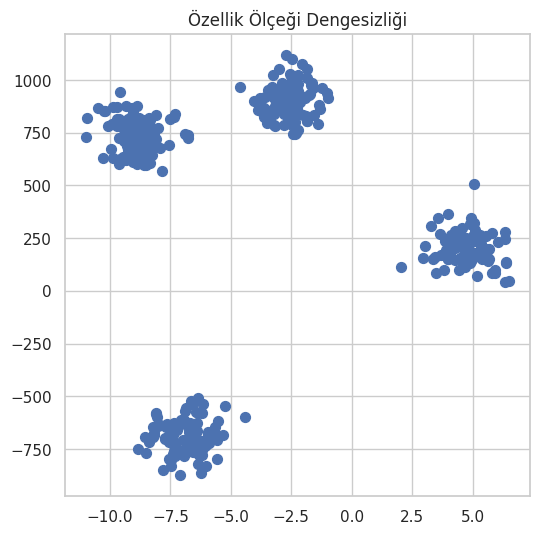

In [13]:
X_scaled_problem = X.copy()
X_scaled_problem[:,1] = X_scaled_problem[:,1] * 100

plt.figure(figsize=(6,6))
plt.scatter(X_scaled_problem[:,0], X_scaled_problem[:,1], s=50)
plt.title("Özellik Ölçeği Dengesizliği")
plt.show()

Ölçeklendirmeden K-ortalamaları uygulanması:

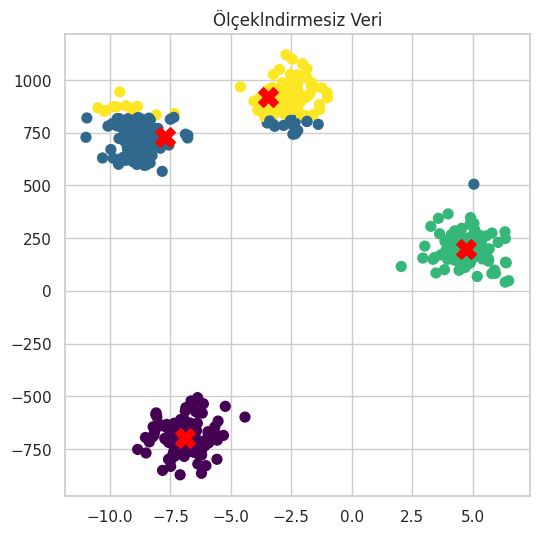

In [24]:
km_no_scale = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_no_scale = km_no_scale.fit_predict(X_scaled_problem)

plt.figure(figsize=(6,6))
plt.scatter(X_scaled_problem[:,0], X_scaled_problem[:,1],
            c=labels_no_scale, cmap="viridis", s=50)
plt.scatter(km_no_scale.cluster_centers_[:,0],
            km_no_scale.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Ölçeklndirmesiz Veri")
plt.show()

Şimdi ölçekleyelim :

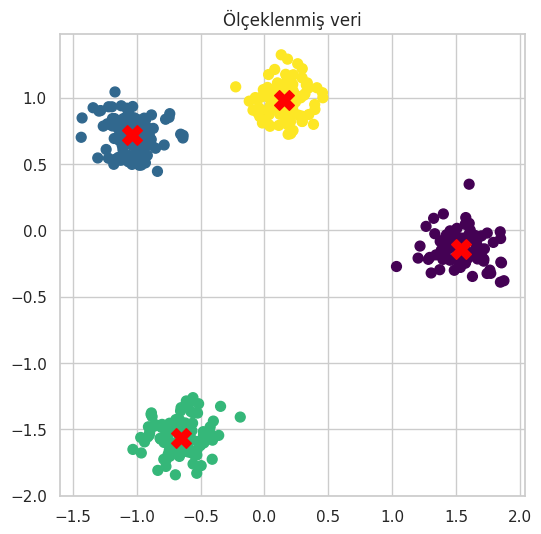

In [26]:
scaler = StandardScaler()
X_corrected = scaler.fit_transform(X_scaled_problem)

km_scaled = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_corrected)

plt.figure(figsize=(6,6))
plt.scatter(X_corrected[:,0], X_corrected[:,1],
            c=labels_scaled, cmap="viridis", s=50)
plt.scatter(km_scaled.cluster_centers_[:,0],
            km_scaled.cluster_centers_[:,1],
            c="red", s=200, marker="X")

plt.title("Ölçeklenmiş veri")
plt.show()